# Day 23 — Seasons
### #30DayChartChallenge | April 2026

**When Spring Arrives: 1,200 Years of Kyoto Cherry Blossom Bloom Dates.**

**Data:** [Aono & Kazui (2008), Int. J. Climatol.](https://doi.org/10.1002/joc.1594), extended with JMA observations.  
**Source CSV:** [GitHub — Ryo-N7/sakura_bloom](https://github.com/Ryo-N7/sakura_bloom)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sysfonts

Loading required package: showtextdb



In [2]:
font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 14, repr.plot.height = 8, repr.plot.res = 300)

In [3]:
bg_col     <- "#0a0e17"
text_col   <- "#e0e6f0"
grid_col   <- "#1a2030"
sakura_col <- "#f7a8c4"
trend_col  <- "#ff4d6d"

bloom_palette <- c(
  "#ff1a5e", "#ff4d7d", "#ff7fa3", "#f7a8c4",
  "#c9a8c9", "#8e7dbe", "#5c5a9e", "#2e2b5f"
)

doy_to_label <- function(d) {
  format(as.Date(d - 1, origin = "2024-01-01"), "%b %d")
}

In [4]:
raw <- read.csv("../../data/day_23/kyoto_cherry_bloom.csv",
                stringsAsFactors = FALSE)

df <- raw %>%
  select(year = AD, doy = Full.flowering.date..DOY.) %>%
  filter(!is.na(doy), doy > 60)

jma_recent <- data.frame(
  year = 2016:2024,
  doy  = c(93, 97, 87, 96, 90, 85, 95, 87, 96)
)

df <- bind_rows(df, jma_recent) %>% arrange(year)

cat("Records:", nrow(df), "| Span:", min(df$year), "\u2013", max(df$year), "\n")
cat("Earliest bloom: DOY", min(df$doy), "(", df$year[which.min(df$doy)], ")\n")
cat("Latest bloom:   DOY", max(df$doy), "(", df$year[which.max(df$doy)], ")\n")

Records: 836 | Span: 812 – 2024 
Earliest bloom: DOY 85 ( 2021 )
Latest bloom:   DOY 124 ( 1323 )


## Plot 1 — Scatter + Loess

`geom_smooth()` using formula = 'y ~ x'


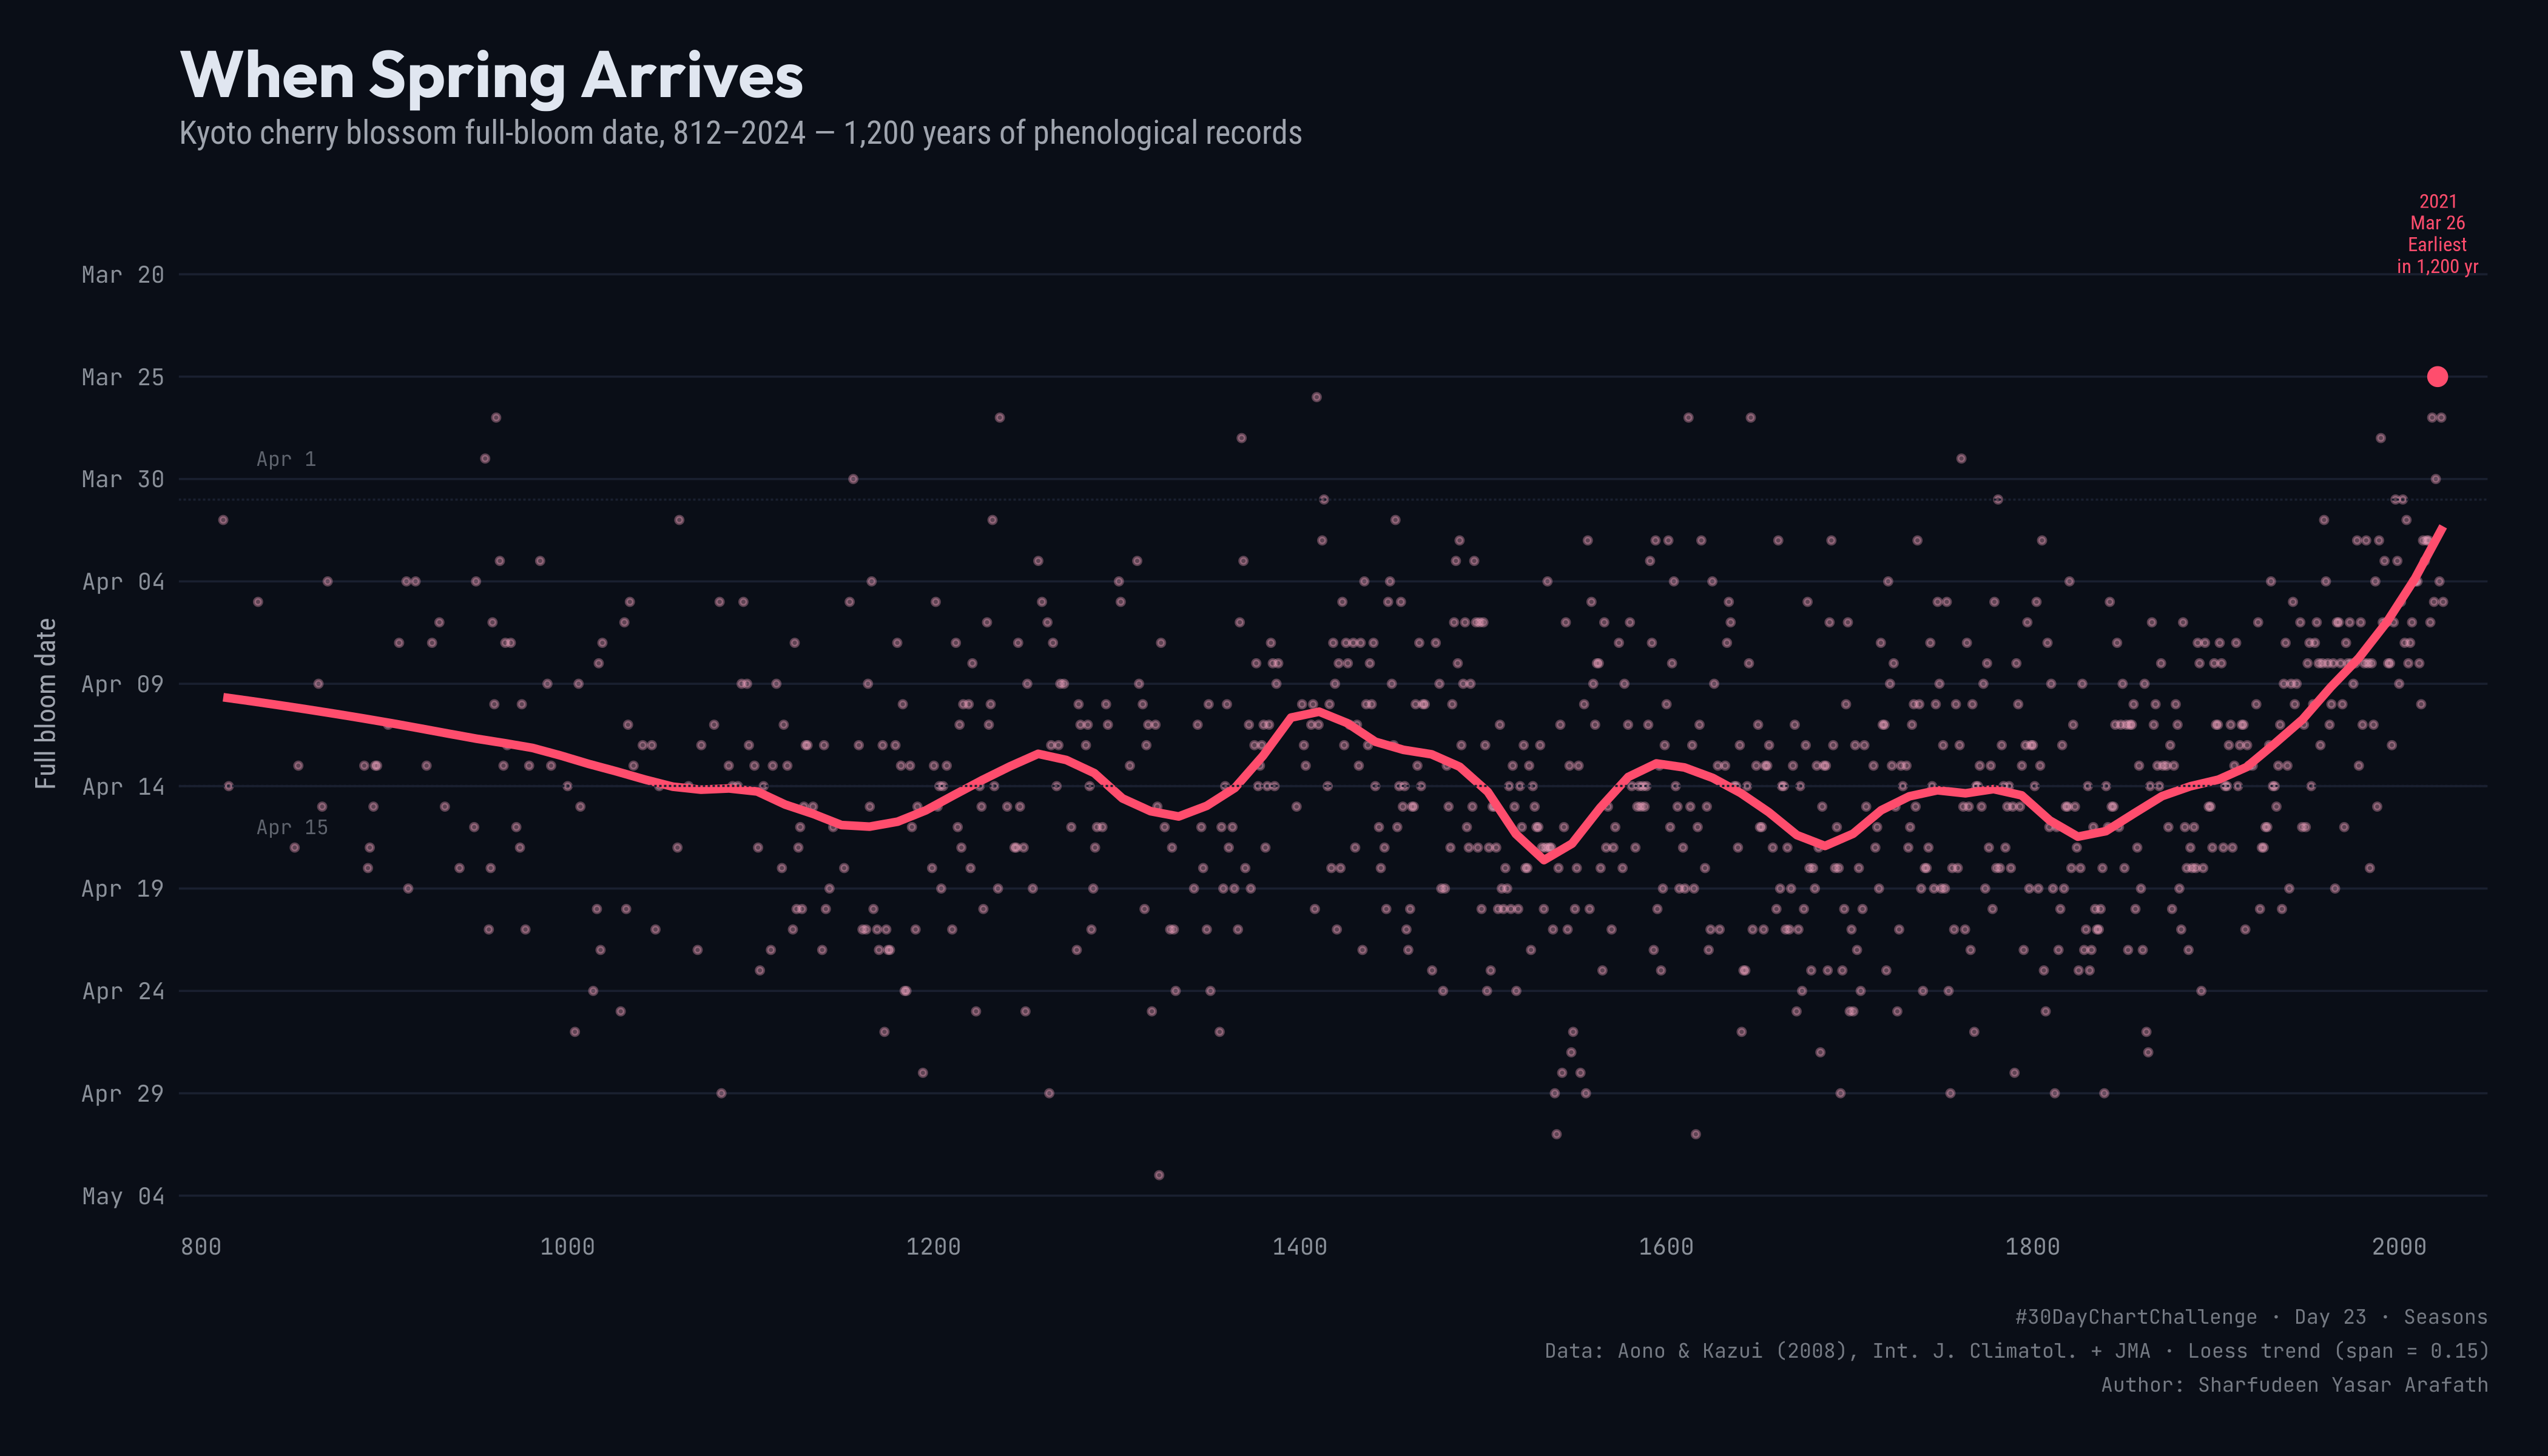

In [5]:
p1 <- ggplot(df, aes(x = year, y = doy)) +
  geom_point(colour = sakura_col, alpha = 0.35, size = 0.8) +
  geom_smooth(method = "loess", span = 0.15, se = FALSE,
              colour = trend_col, linewidth = 1.2) +
  geom_hline(yintercept = c(91, 105), colour = grid_col,
             linewidth = 0.3, linetype = "dashed") +
  annotate("text", x = 830, y = 89, label = "Apr 1",
           family = "jetbrains", size = 2.8,
           colour = alpha(text_col, 0.4), hjust = 0) +
  annotate("text", x = 830, y = 107, label = "Apr 15",
           family = "jetbrains", size = 2.8,
           colour = alpha(text_col, 0.4), hjust = 0) +
  annotate("text", x = 2021, y = 78, label = "2021\nMar 26\nEarliest\nin 1,200 yr",
           family = "roboto_condensed", size = 2.8,
           colour = trend_col, hjust = 0.5, lineheight = 0.9) +
  geom_point(data = filter(df, year == 2021),
             colour = trend_col, size = 3, shape = 21,
             fill = trend_col, stroke = 0.5) +
  scale_x_continuous(breaks = seq(800, 2000, 200),
                     labels = function(x) as.character(x),
                     expand = expansion(mult = c(0.02, 0.02))) +
  scale_y_reverse(breaks = seq(80, 130, 5),
                  labels = doy_to_label,
                  expand = expansion(mult = c(0.05, 0.05))) +
  labs(
    title    = "When Spring Arrives",
    subtitle = "Kyoto cherry blossom full-bloom date, 812\u20132024 \u2014 1,200 years of phenological records",
    caption  = "#30DayChartChallenge \u00b7 Day 23 \u00b7 Seasons\nData: Aono & Kazui (2008), Int. J. Climatol. + JMA \u00b7 Loess trend (span = 0.15)\nAuthor: Sharfudeen Yasar Arafath",
    x = NULL, y = "Full bloom date"
  ) +
  theme_minimal(base_family = "outfit", base_size = 14) +
  theme(
    plot.background    = element_rect(fill = bg_col, colour = NA),
    panel.background   = element_rect(fill = bg_col, colour = NA),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(colour = grid_col, linewidth = 0.3),
    plot.title    = element_text(family = "outfit", face = "bold",
                                size = 26, colour = text_col,
                                margin = margin(b = 4)),
    plot.subtitle = element_text(family = "roboto_condensed",
                                size = 13, colour = alpha(text_col, 0.7),
                                margin = margin(b = 14)),
    plot.caption  = element_text(family = "jetbrains", size = 8,
                                colour = alpha(text_col, 0.5),
                                hjust = 1, lineheight = 1.4,
                                margin = margin(t = 20)),
    axis.text     = element_text(family = "jetbrains", size = 9,
                                colour = alpha(text_col, 0.6)),
    axis.title.y  = element_text(family = "roboto_condensed", size = 11,
                                colour = alpha(text_col, 0.7),
                                margin = margin(r = 8)),
    plot.margin   = margin(20, 24, 24, 14)
  )

p1

In [6]:
ggsave("../../chart/day_23_seasons.png", plot = p1,
       width = 14, height = 8, dpi = 300, bg = bg_col)
cat("\u2705 Scatter saved\n")

`geom_smooth()` using formula = 'y ~ x'


✅ Scatter saved


## Plot 2 — Heatmap Grid

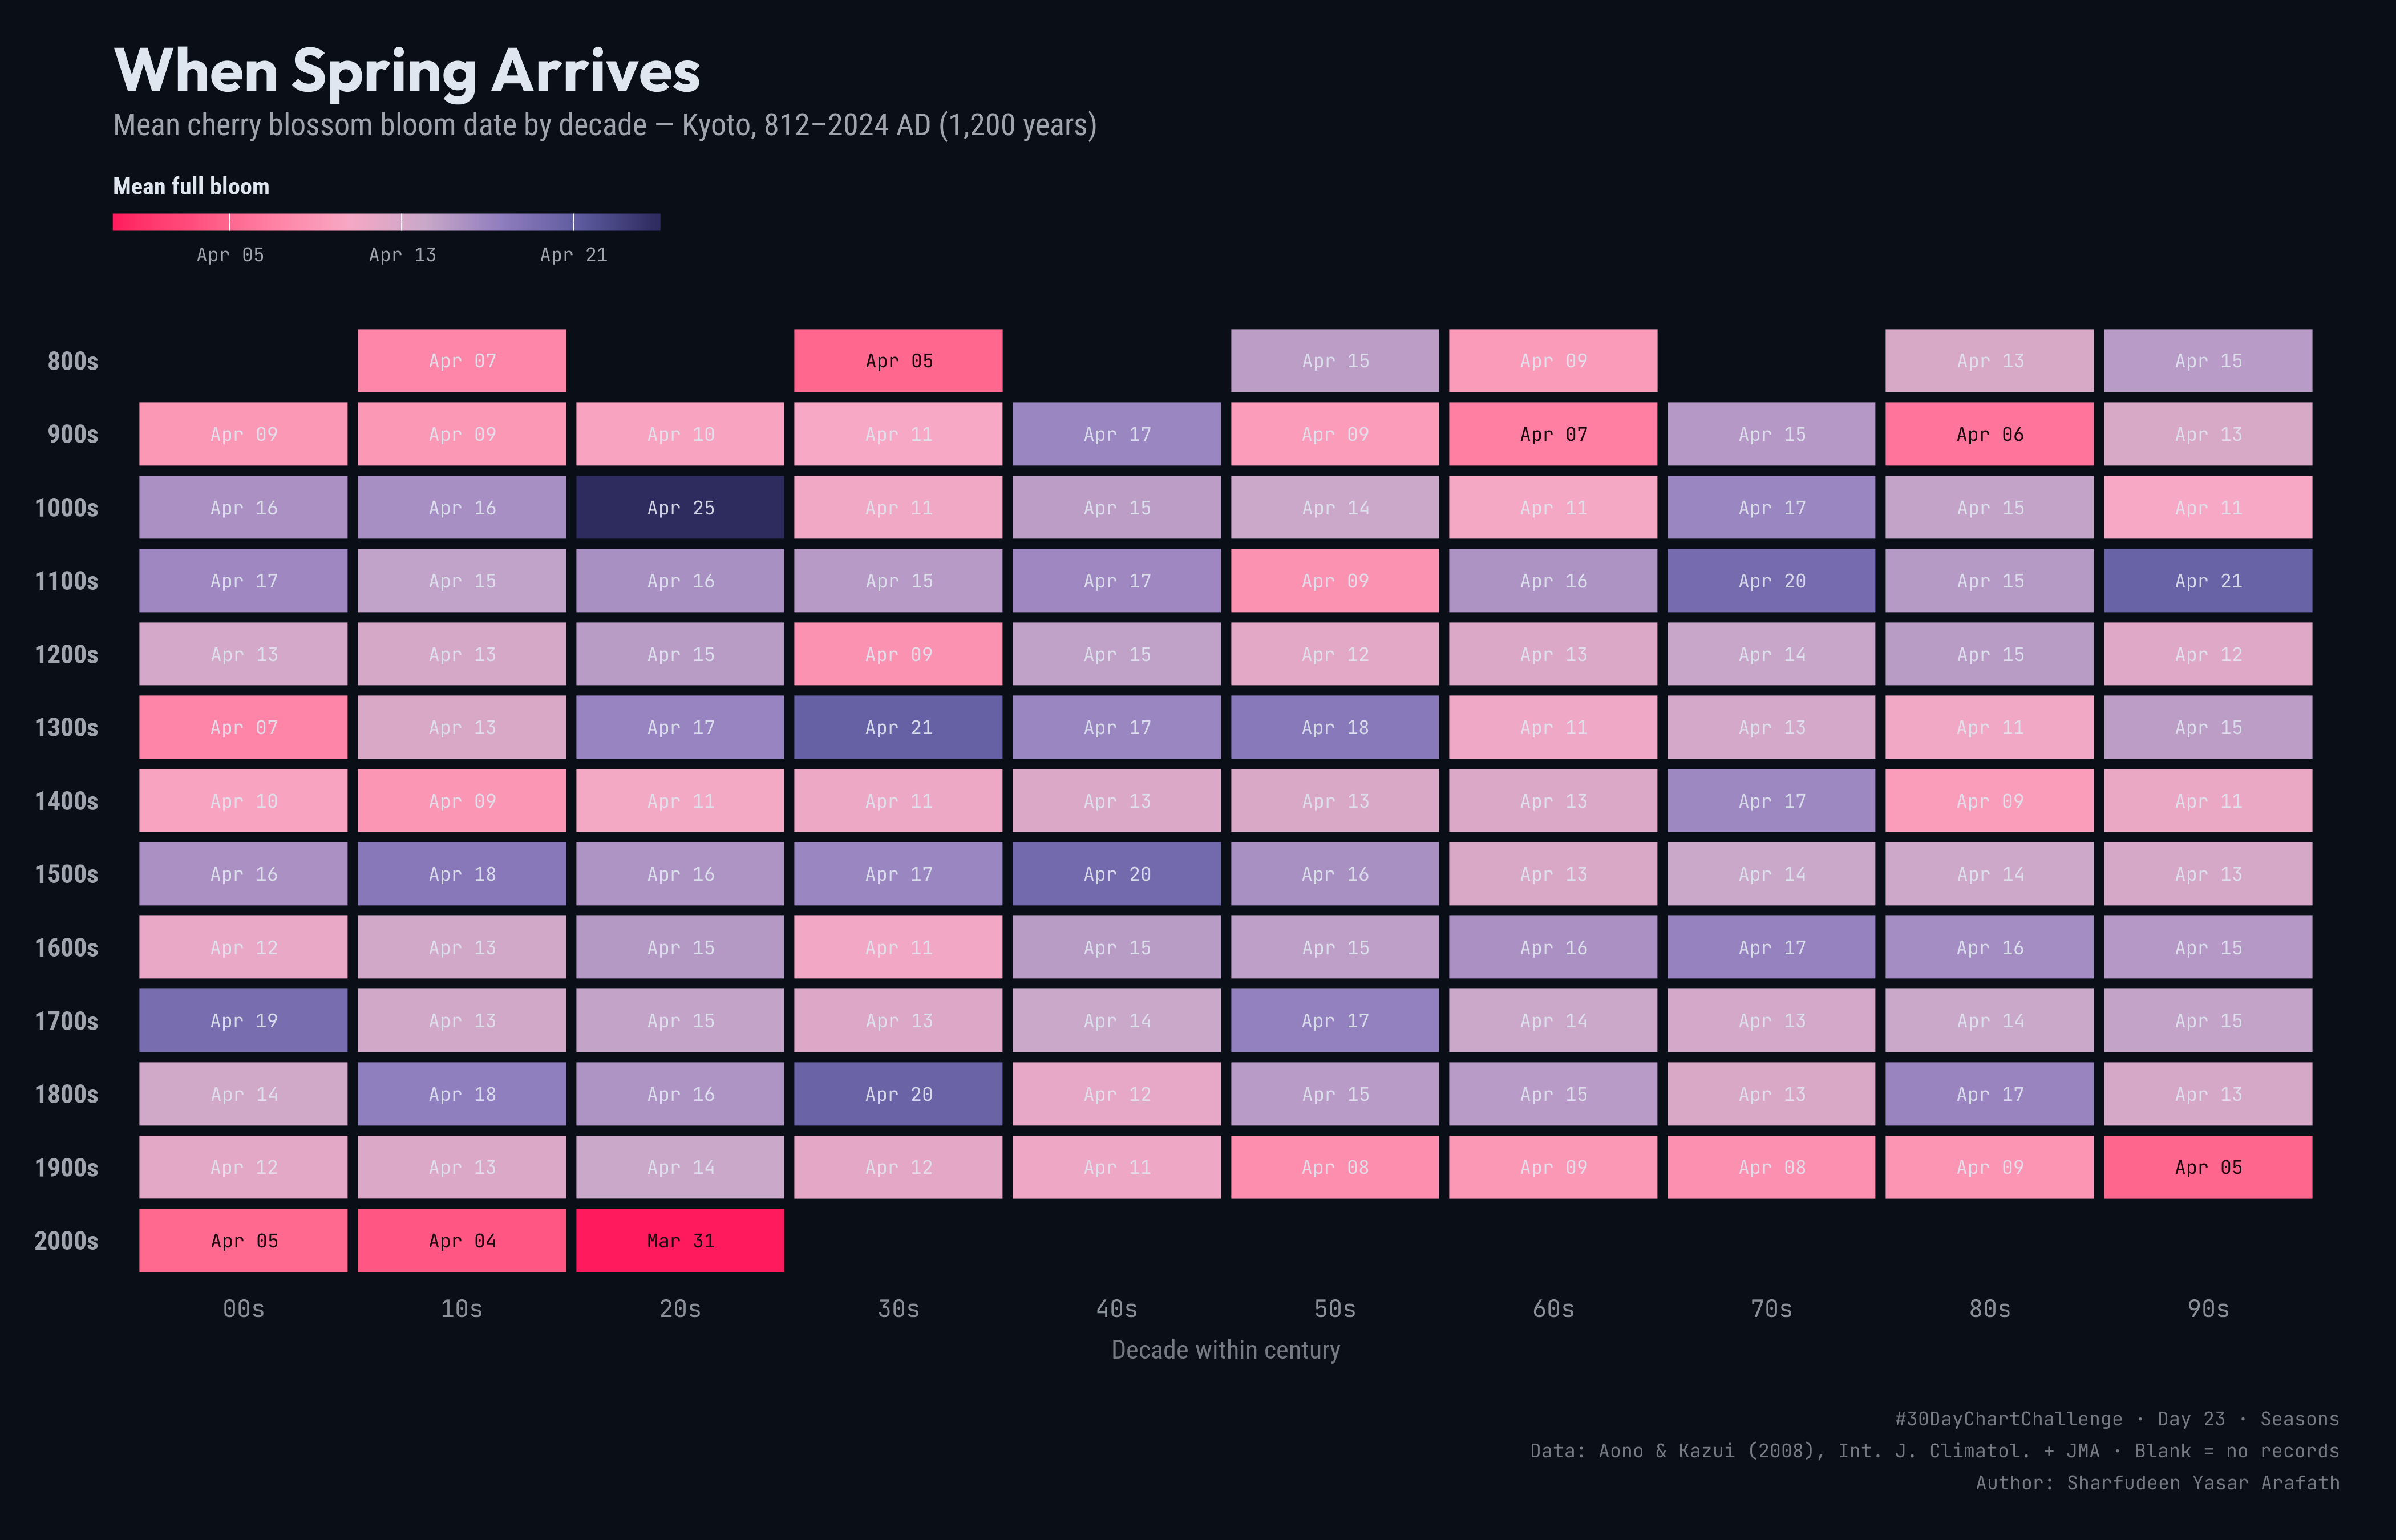

In [7]:
options(repr.plot.width = 14, repr.plot.height = 9, repr.plot.res = 300)

grid_df <- df %>%
  mutate(
    century    = floor(year / 100),
    decade     = floor((year %% 100) / 10),
    cent_label = paste0(century * 100, "s"),
    dec_label  = sprintf("%02ds", decade * 10)
  ) %>%
  group_by(century, decade, cent_label, dec_label) %>%
  summarise(mean_doy = mean(doy), n = n(), .groups = "drop") %>%
  mutate(
    cent_label = factor(cent_label,
      levels = rev(paste0(seq(8, 20) * 100, "s"))),
    dec_label  = factor(dec_label,
      levels = sprintf("%02ds", seq(0, 9) * 10))
  )

p2 <- ggplot(grid_df, aes(x = dec_label, y = cent_label, fill = mean_doy)) +
  geom_tile(colour = bg_col, linewidth = 1.5) +
  geom_text(aes(label = doy_to_label(round(mean_doy))),
            family = "jetbrains", size = 2.8,
            colour = ifelse(grid_df$mean_doy < 98, "#1a0a10", alpha(text_col, 0.9))) +
  scale_fill_gradientn(
    colours = bloom_palette,
    name    = "Mean full bloom",
    breaks  = c(88, 96, 104, 112),
    labels  = doy_to_label,
    guide   = guide_colourbar(
      title.position = "top",
      barwidth  = unit(16, "lines"),
      barheight = unit(0.5, "lines"),
      direction = "horizontal"
    )
  ) +
  labs(
    title    = "When Spring Arrives",
    subtitle = "Mean cherry blossom bloom date by decade \u2014 Kyoto, 812\u20132024 AD (1,200 years)",
    caption  = "#30DayChartChallenge \u00b7 Day 23 \u00b7 Seasons\nData: Aono & Kazui (2008), Int. J. Climatol. + JMA \u00b7 Blank = no records\nAuthor: Sharfudeen Yasar Arafath",
    x = "Decade within century", y = NULL
  ) +
  theme_minimal(base_family = "outfit", base_size = 14) +
  theme(
    plot.background  = element_rect(fill = bg_col, colour = NA),
    panel.background = element_rect(fill = bg_col, colour = NA),
    panel.grid       = element_blank(),
    plot.title    = element_text(family = "outfit", face = "bold",
                                size = 26, colour = text_col,
                                margin = margin(b = 4)),
    plot.subtitle = element_text(family = "roboto_condensed",
                                size = 13, colour = alpha(text_col, 0.7),
                                margin = margin(b = 14)),
    plot.caption  = element_text(family = "jetbrains", size = 8,
                                colour = alpha(text_col, 0.5),
                                hjust = 1, lineheight = 1.4,
                                margin = margin(t = 20)),
    axis.text.x   = element_text(family = "jetbrains", size = 10,
                                colour = alpha(text_col, 0.6)),
    axis.text.y   = element_text(family = "roboto_condensed", size = 11,
                                colour = alpha(text_col, 0.7),
                                face = "bold"),
    axis.title.x  = element_text(family = "roboto_condensed", size = 11,
                                colour = alpha(text_col, 0.5),
                                margin = margin(t = 8)),
    legend.position      = "top",
    legend.justification = "left",
    legend.title  = element_text(family = "roboto_condensed", size = 10,
                                colour = text_col, face = "bold"),
    legend.text   = element_text(family = "jetbrains", size = 8,
                                colour = alpha(text_col, 0.7)),
    legend.margin = margin(b = 8),
    plot.margin   = margin(20, 24, 20, 14)
  )

p2

In [8]:
ggsave("../../chart/day_23_seasons_heatmap.png", plot = p2,
       width = 14, height = 9, dpi = 300, bg = bg_col)
cat("\u2705 Heatmap saved\n")

✅ Heatmap saved
